# Exploratory Data Analysis (EDA)
## Survey Kepuasan Fasilitas Kampus ITSB 2026
**Kelompok 7 — Sains Data**

| Nama | NIM |
|------|-----|
| Putri Adria Garini | 52250002 |
| Yosef Teofani Tamba | 52250007 |
| Jihan Ramadhani Deandri | 52250024 |
| Hanafi Malik Rifai | 52250032 |

---

In [4]:
from google.colab import files
uploaded = files.upload()

Saving Dataset Kuesioner.xlsx to Dataset Kuesioner (2).xlsx


## 1. Import Library & Load Data

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
COLORS = ['#4285F4','#EA4335','#FBBC05','#34A853','#9C6FE4','#FF7C6B','#34C79A','#FF6B9D']
sns.set_theme(style='whitegrid', palette=COLORS)

# Load dataset
df = pd.read_excel('Dataset Kuesioner (2).xlsx')
print(f'Dataset berhasil dimuat: {df.shape[0]} baris x {df.shape[1]} kolom')
df.head()

Dataset berhasil dimuat: 127 baris x 23 kolom


,Timestamp,Tipe,Jenis Kunjungan,Nama,NIM,Prodi,Angkatan,Q1,Q2,Q3,...,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Q14,Q15,Saran
0,"4/5/2026, 16.46.23",NaN,NaN,Annisa Mutya Amanda,26250016,Teknik Metalurgi,2025.0,4,5.0,3,...,5.0,1,3,3,4,4.0,3.0,5.0,5.0,wifi kampus yaaa akhir akhir ini selalu ngelag...
1,"4/5/2026, 17.13.33",NaN,NaN,Ihsan Riyadi,27250001,Teknik Perminyakan,2025.0,5,5.0,2,...,5.0,1,1,5,2,5.0,5.0,1.0,2.0,NaN
2,"4/5/2026, 17.18.13",NaN,NaN,Alya Maura Raditha,52240003,Sains Data,2024.0,2,4.0,3,...,2.0,3,4,4,4,4.0,3.0,3.0,5.0,"Lebih sering cek kondisi masing-masing kelas, ..."
3,"4/5/2026, 18.45.57",NaN,NaN,NUR FAJRIN,25258059,Teknik Pertambangan,2025.0,4,4.0,4,...,4.0,4,4,4,4,4.0,4.0,4.0,4.0,UNTUK ALAT-ALAT LABORATORIUM MASIH MINIM TERSE...
4,"4/5/2026, 18.59.29",NaN,NaN,Muhammad Arfy Rafa F,14123008,Informatika,2023.0,4,4.0,4,...,5.0,5,4,4,2,4.0,5.0,4.0,5.0,"Tolong parkiran sepeda di kasih canopy , seped..."


## 2. Preprocessing & Cleaning

In [8]:
# Kolom pertanyaan
Q_COLS = [f'Q{i}' for i in range(1, 16)]
Q_LABELS = [
    'Q1: Kebersihan', 'Q2: Ruang Kelas', 'Q3: Lab', 'Q4: Alat Lab',
    'Q5: Perpustakaan', 'Q6: Kantin', 'Q7: Toilet', 'Q8: WiFi',
    'Q9: eCampuz', 'Q10: Parkir', 'Q11: Diskusi', 'Q12: Mushola',
    'Q13: Olahraga', 'Q14: Keamanan', 'Q15: Administrasi'
]

# Konversi kolom Q ke numerik
for col in Q_COLS:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Bersihkan kolom Tipe
df['Tipe'] = df['Tipe'].fillna('Mahasiswa').str.strip()

print('Jumlah missing values per kolom:')
print(df[Q_COLS].isnull().sum())
print(f'\nTotal responden: {len(df)}')
print(f'Distribusi Tipe:')
print(df['Tipe'].value_counts())

Jumlah missing values per kolom:
Q1     0
Q2     1
Q3     0
Q4     0
Q5     1
Q6     0
Q7     1
Q8     0
Q9     0
Q10    0
Q11    0
Q12    1
Q13    1
Q14    1
Q15    1
dtype: int64

Total responden: 127
Distribusi Tipe:
Tipe
Mahasiswa              77
Tamu/Pengunjung        32
Orang Tua Mahasiswa    10
Calon Mahasiswa         8
Name: count, dtype: int64


In [9]:
# Info dasar dataset
print('=== INFO DATASET ===')
df.info()
print('\n=== STATISTIK DESKRIPTIF Q1-Q15 ===')
df[Q_COLS].describe().round(3)

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127 entries, 0 to 126
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Timestamp        127 non-null    object 
 1   Tipe             127 non-null    object 
 2   Jenis Kunjungan  0 non-null      float64
 3   Nama             127 non-null    object 
 4   NIM              77 non-null     object 
 5   Prodi            77 non-null     object 
 6   Angkatan         77 non-null     float64
 7   Q1               127 non-null    int64  
 8   Q2               126 non-null    float64
 9   Q3               127 non-null    int64  
 10  Q4               127 non-null    int64  
 11  Q5               126 non-null    float64
 12  Q6               127 non-null    int64  
 13  Q7               126 non-null    float64
 14  Q8               127 non-null    int64  
 15  Q9               127 non-null    int64  
 16  Q10              127 non-null    int64  


,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Q14,Q15
count,127.000,126.000,127.000,127.000,126.000,127.000,126.000,127.000,127.000,127.000,127.000,126.000,126.000,126.000,126.000
mean,3.937,3.849,3.583,3.535,3.738,3.882,3.897,3.071,3.283,3.811,3.772,3.952,3.476,3.825,3.683
std,1.006,0.980,1.035,1.060,1.044,0.989,1.042,1.432,1.214,0.982,1.033,1.003,1.171,1.051,1.071
min,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,2.000,1.000,1.000,1.000,1.000,1.000
25%,3.000,3.000,3.000,3.000,3.000,3.000,3.000,2.000,2.000,3.000,3.000,3.000,3.000,3.000,3.000
50%,4.000,4.000,4.000,3.000,4.000,4.000,4.000,3.000,3.000,4.000,4.000,4.000,3.000,4.000,4.000
75%,5.000,5.000,4.000,4.000,5.000,5.000,5.000,4.000,4.000,5.000,5.000,5.000,4.750,5.000,5.000
max,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000


## 3. Statistik Deskriptif

In [10]:
# Hitung mean, median, std, min, max per pertanyaan
desc = pd.DataFrame({
    'Indikator': Q_LABELS,
    'Mean':   df[Q_COLS].mean().round(3).values,
    'Median': df[Q_COLS].median().round(3).values,
    'Std':    df[Q_COLS].std().round(3).values,
    'Min':    df[Q_COLS].min().values,
    'Max':    df[Q_COLS].max().values,
})
desc = desc.sort_values('Mean', ascending=False).reset_index(drop=True)
print(f"Overall Mean: {df[Q_COLS].mean().mean():.3f}")
print(f"Indikator Tertinggi: {desc.iloc[0]['Indikator']} ({desc.iloc[0]['Mean']})")
print(f"Indikator Terendah: {desc.iloc[-1]['Indikator']} ({desc.iloc[-1]['Mean']})")
desc

Overall Mean: 3.686
Indikator Tertinggi: Q12: Mushola (3.952)
Indikator Terendah: Q8: WiFi (3.071)


,Indikator,Mean,Median,Std,Min,Max
0,Q12: Mushola,3.952,4.0,1.003,1.0,5.0
1,Q1: Kebersihan,3.937,4.0,1.006,1.0,5.0
2,Q7: Toilet,3.897,4.0,1.042,1.0,5.0
3,Q6: Kantin,3.882,4.0,0.989,1.0,5.0
4,Q2: Ruang Kelas,3.849,4.0,0.980,1.0,5.0
5,Q14: Keamanan,3.825,4.0,1.051,1.0,5.0
6,Q10: Parkir,3.811,4.0,0.982,2.0,5.0
7,Q11: Diskusi,3.772,4.0,1.033,1.0,5.0
8,Q5: Perpustakaan,3.738,4.0,1.044,1.0,5.0
9,Q15: Administrasi,3.683,4.0,1.071,1.0,5.0


## 4. Visualisasi — Rata-rata Skor per Indikator

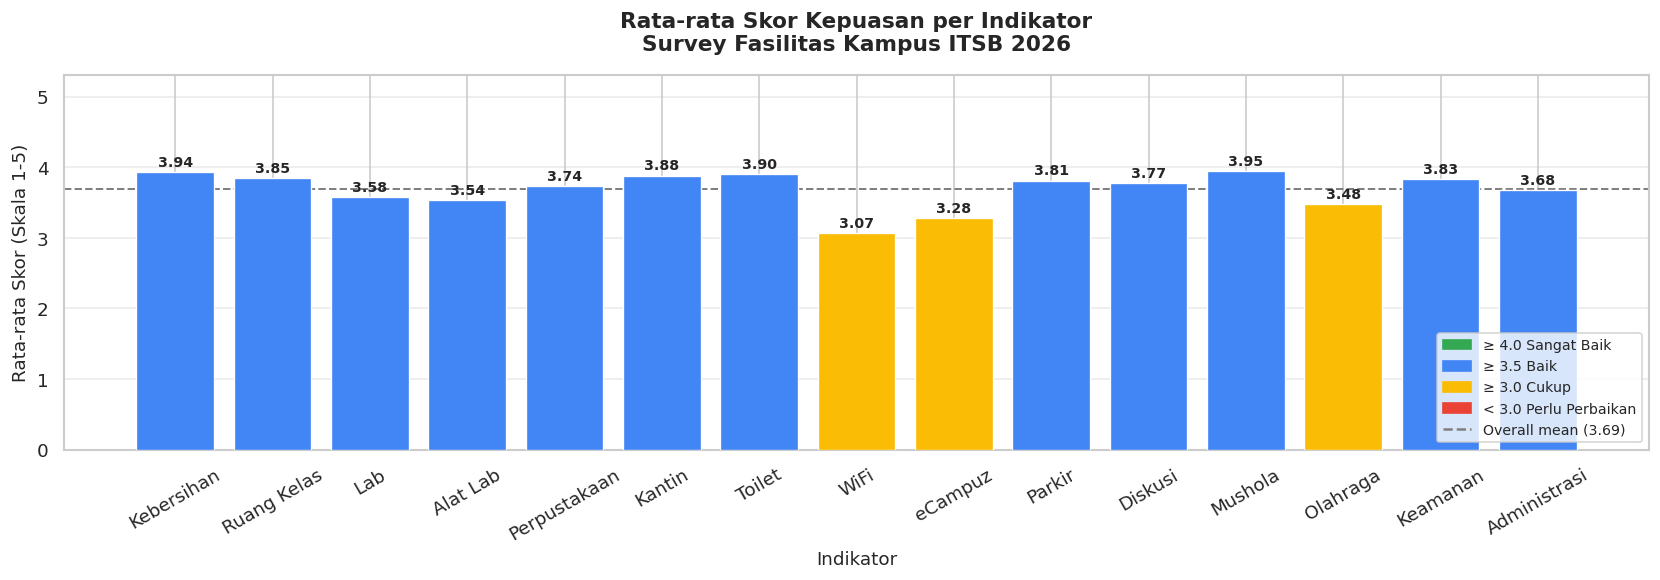

Gambar disimpan: fig1_mean_per_indikator.png


In [11]:
means = df[Q_COLS].mean().reset_index()
means.columns = ['Q', 'Mean']
means['Label'] = Q_LABELS
means['Short'] = [l.split(': ')[1] for l in Q_LABELS]

def score_color(v):
    if v >= 4.0: return '#34A853'
    if v >= 3.5: return '#4285F4'
    if v >= 3.0: return '#FBBC05'
    return '#EA4335'

colors = [score_color(v) for v in means['Mean']]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(means['Short'], means['Mean'], color=colors, edgecolor='white', linewidth=0.8, zorder=3)

for bar, val in zip(bars, means['Mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.04,
            f'{val:.2f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.axhline(y=df[Q_COLS].mean().mean(), color='gray', linestyle='--', linewidth=1.2, label=f'Rata-rata keseluruhan ({df[Q_COLS].mean().mean():.2f})', zorder=2)
ax.set_ylim(0, 5.3)
ax.set_xlabel('Indikator', fontsize=11)
ax.set_ylabel('Rata-rata Skor (Skala 1-5)', fontsize=11)
ax.set_title('Rata-rata Skor Kepuasan per Indikator\nSurvey Fasilitas Kampus ITSB 2026', fontsize=13, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.4, zorder=1)

legend_patches = [
    mpatches.Patch(color='#34A853', label='≥ 4.0 Sangat Baik'),
    mpatches.Patch(color='#4285F4', label='≥ 3.5 Baik'),
    mpatches.Patch(color='#FBBC05', label='≥ 3.0 Cukup'),
    mpatches.Patch(color='#EA4335', label='< 3.0 Perlu Perbaikan'),
]
ax.legend(handles=legend_patches + [plt.Line2D([0],[0], color='gray', linestyle='--', label=f'Overall mean ({df[Q_COLS].mean().mean():.2f})')],
          loc='lower right', fontsize=8.5)

plt.tight_layout()
plt.savefig('fig1_mean_per_indikator.png', bbox_inches='tight')
plt.show()
print('Gambar disimpan: fig1_mean_per_indikator.png')

## 5. Distribusi Frekuensi Jawaban

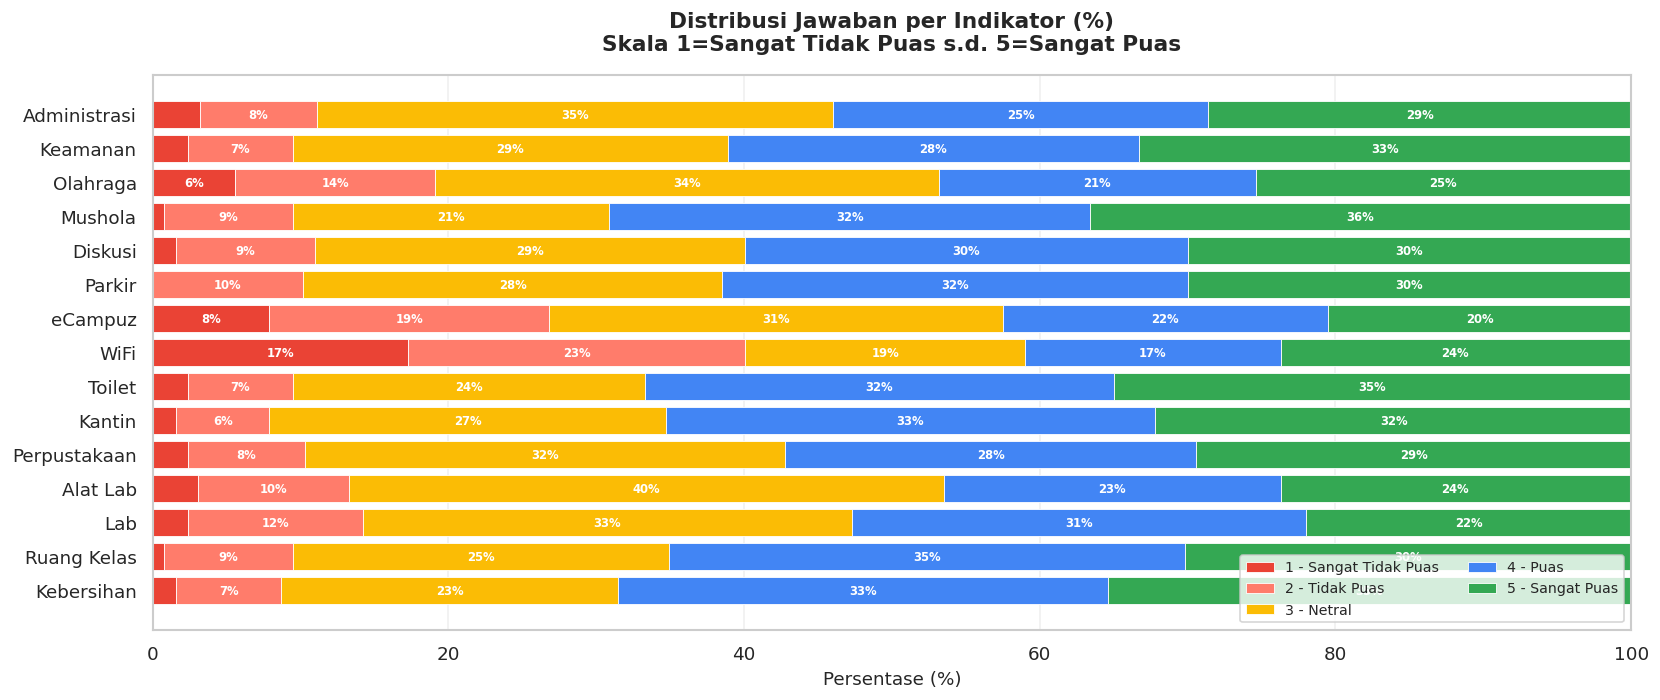

In [12]:
# Stacked bar distribusi jawaban semua indikator
dist_pct = pd.DataFrame()
for col, label in zip(Q_COLS, [l.split(': ')[1] for l in Q_LABELS]):
    counts = df[col].value_counts().reindex([1,2,3,4,5], fill_value=0)
    pct = (counts / counts.sum() * 100).round(1)
    dist_pct[label] = pct

dist_pct = dist_pct.T

fig, ax = plt.subplots(figsize=(14, 6))
score_colors = ['#EA4335','#FF7C6B','#FBBC05','#4285F4','#34A853']
score_labels = ['1 - Sangat Tidak Puas','2 - Tidak Puas','3 - Netral','4 - Puas','5 - Sangat Puas']

left = np.zeros(len(dist_pct))
for i, (score, color, lbl) in enumerate(zip([1,2,3,4,5], score_colors, score_labels)):
    vals = dist_pct[score].values
    ax.barh(dist_pct.index, vals, left=left, color=color, label=lbl, edgecolor='white', linewidth=0.5)
    for j, (v, l) in enumerate(zip(vals, left)):
        if v >= 5:
            ax.text(l + v/2, j, f'{v:.0f}%', ha='center', va='center', fontsize=7, color='white', fontweight='bold')
    left += vals

ax.set_xlabel('Persentase (%)', fontsize=11)
ax.set_title('Distribusi Jawaban per Indikator (%)\nSkala 1=Sangat Tidak Puas s.d. 5=Sangat Puas', fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=8.5, ncol=2)
ax.set_xlim(0, 100)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig2_distribusi_jawaban.png', bbox_inches='tight')
plt.show()

## 6. Analisis Segmentasi — Distribusi Responden

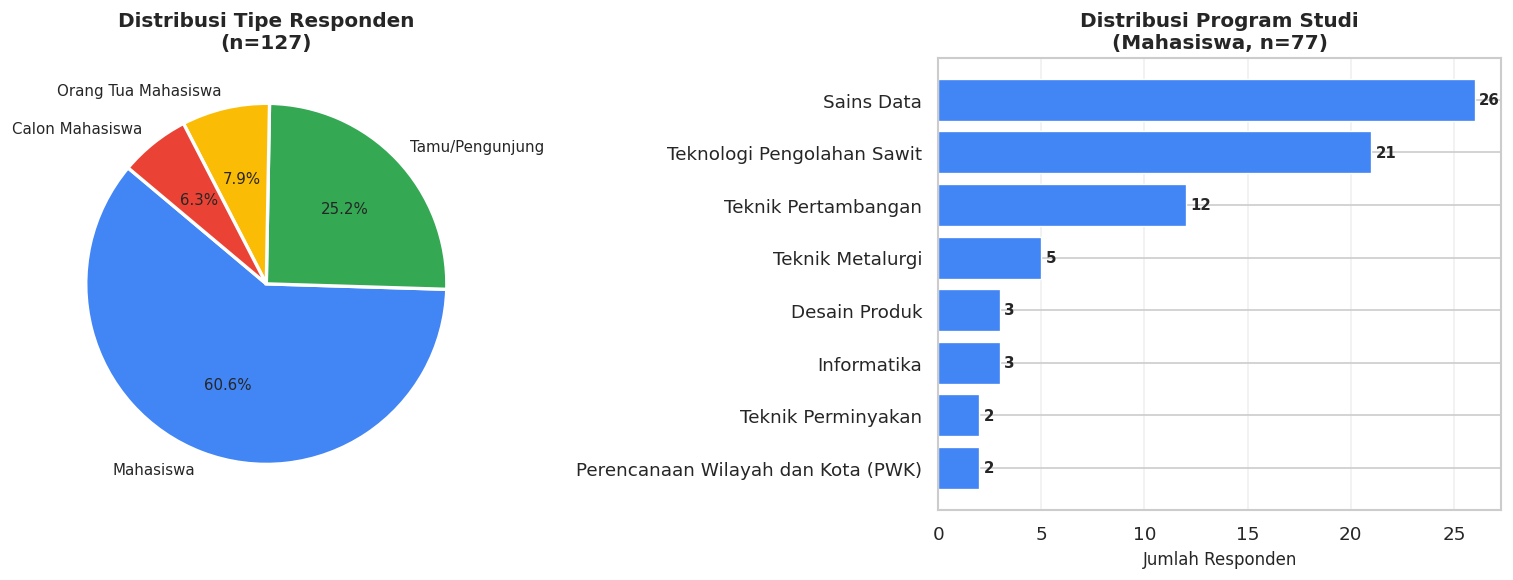

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart Tipe Responden
tipe_counts = df['Tipe'].value_counts()
wedge_colors = ['#4285F4','#34A853','#FBBC05','#EA4335','#9C6FE4']
axes[0].pie(tipe_counts.values, labels=tipe_counts.index,
            autopct='%1.1f%%', startangle=140,
            colors=wedge_colors[:len(tipe_counts)],
            wedgeprops={'edgecolor':'white','linewidth':2},
            textprops={'fontsize':9})
axes[0].set_title('Distribusi Tipe Responden\n(n=127)', fontsize=12, fontweight='bold')

# Bar chart Prodi (mahasiswa only)
mhs = df[df['Tipe'].str.contains('Mahasiswa', na=False)]
prodi_counts = mhs['Prodi'].value_counts().head(8)
axes[1].barh(prodi_counts.index[::-1], prodi_counts.values[::-1],
             color='#4285F4', edgecolor='white', linewidth=0.8)
for i, (v, label) in enumerate(zip(prodi_counts.values[::-1], prodi_counts.index[::-1])):
    axes[1].text(v + 0.2, i, str(v), va='center', fontsize=9, fontweight='bold')
axes[1].set_xlabel('Jumlah Responden', fontsize=10)
axes[1].set_title('Distribusi Program Studi\n(Mahasiswa, n=77)', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('fig3_distribusi_responden.png', bbox_inches='tight')
plt.show()

## 7. Perbandingan Skor per Segmen

In [14]:
# Mean per tipe
tipe_means = df.groupby('Tipe')[Q_COLS].mean().round(3)
print('=== Rata-rata Skor per Tipe Responden ===')
tipe_means.T.rename(columns=dict(zip(Q_COLS, [l.split(': ')[1] for l in Q_LABELS])))

=== Rata-rata Skor per Tipe Responden ===


Tipe,Calon Mahasiswa,Mahasiswa,Orang Tua Mahasiswa,Tamu/Pengunjung
Q1,3.500,4.104,3.7,3.719
Q2,3.750,4.000,3.4,3.656
Q3,3.250,3.545,3.7,3.719
Q4,3.375,3.429,3.3,3.906
Q5,3.875,3.737,3.2,3.875
Q6,3.500,3.896,3.9,3.938
Q7,3.375,4.145,3.2,3.656
Q8,3.625,2.649,3.2,3.906
Q9,3.500,2.987,3.3,3.938
Q10,3.250,3.883,4.1,3.688


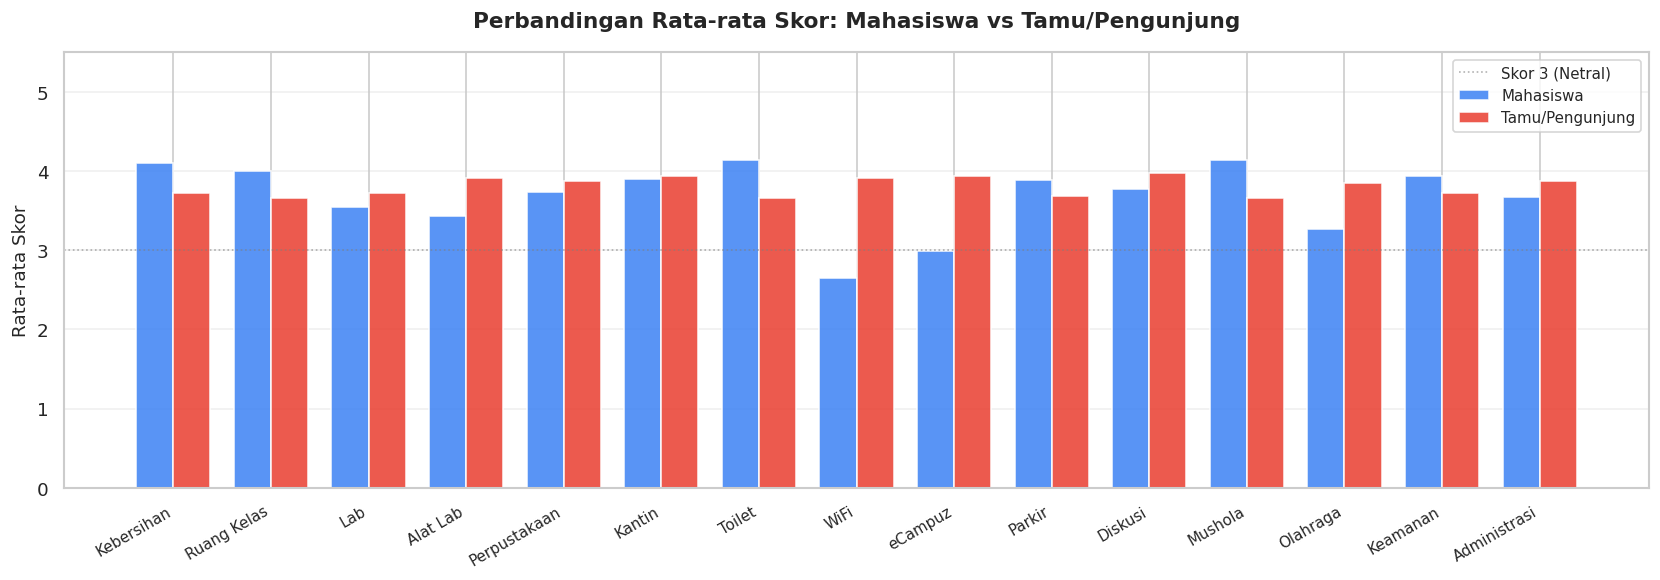

In [15]:
# Grouped bar: Mahasiswa vs Tamu/Pengunjung
tipe_sel = ['Mahasiswa','Tamu/Pengunjung']
tipe_sub = tipe_means.loc[[t for t in tipe_sel if t in tipe_means.index]]

shorts = [l.split(': ')[1] for l in Q_LABELS]
x = np.arange(len(Q_COLS))
width = 0.38

fig, ax = plt.subplots(figsize=(14, 5))
for i, (tipe, color) in enumerate(zip(tipe_sub.index, ['#4285F4','#EA4335'])):
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, tipe_sub.loc[tipe], width, label=tipe, color=color, alpha=0.88, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(shorts, rotation=30, ha='right', fontsize=9)
ax.set_ylim(0, 5.5)
ax.set_ylabel('Rata-rata Skor', fontsize=11)
ax.set_title('Perbandingan Rata-rata Skor: Mahasiswa vs Tamu/Pengunjung', fontsize=13, fontweight='bold', pad=15)
ax.axhline(y=3, color='gray', linestyle=':', linewidth=1, alpha=0.6, label='Skor 3 (Netral)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig4_perbandingan_segmen.png', bbox_inches='tight')
plt.show()

## 8. Radar Chart — Profil Kepuasan per Segmen

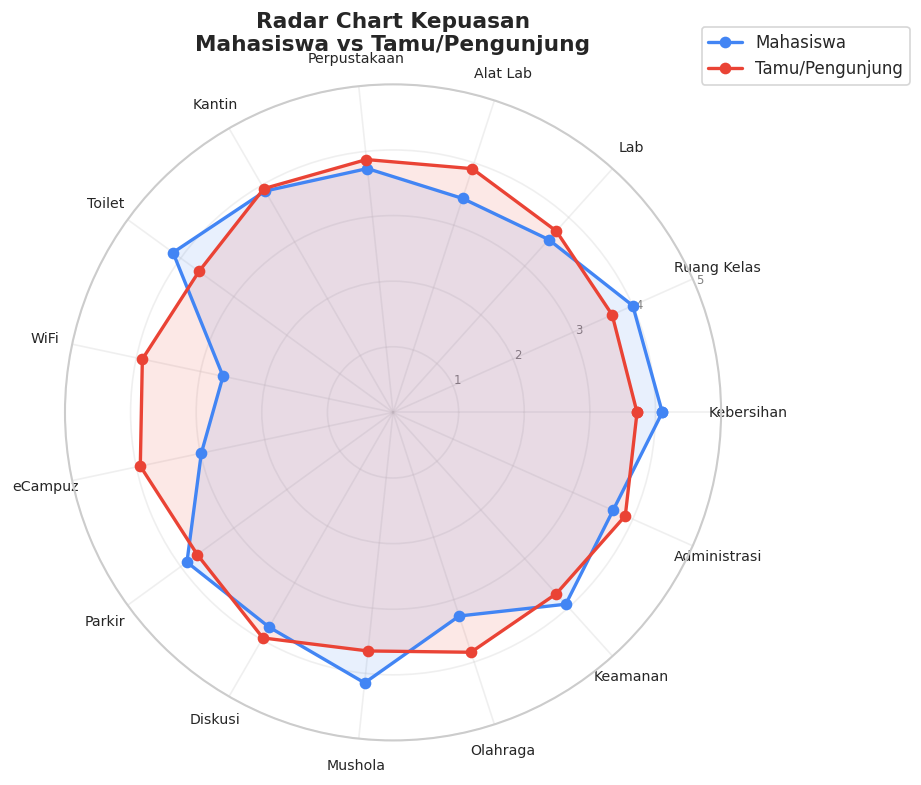

In [16]:
from matplotlib.patches import FancyArrowPatch

categories = [l.split(': ')[1] for l in Q_LABELS]
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

tipe_plot = [t for t in ['Mahasiswa','Tamu/Pengunjung'] if t in tipe_means.index]
colors_radar = ['#4285F4','#EA4335']

for tipe, color in zip(tipe_plot, colors_radar):
    values = tipe_means.loc[tipe, Q_COLS].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=tipe, color=color)
    ax.fill(angles, values, alpha=0.12, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=8.5)
ax.set_ylim(0, 5)
ax.set_yticks([1,2,3,4,5])
ax.set_yticklabels(['1','2','3','4','5'], size=7, color='gray')
ax.set_title('Radar Chart Kepuasan\nMahasiswa vs Tamu/Pengunjung', size=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig5_radar_chart.png', bbox_inches='tight')
plt.show()

## 9. Heatmap Korelasi antar Indikator

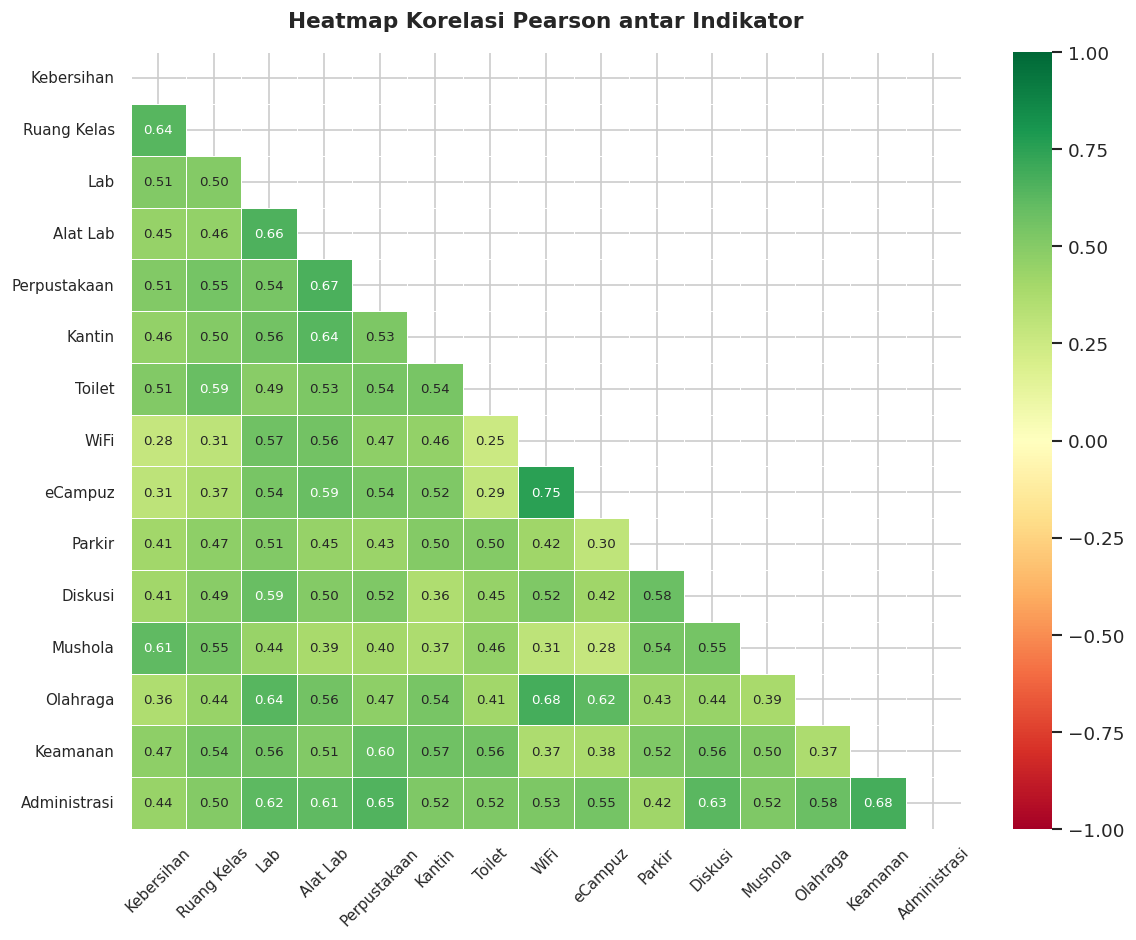

Top 5 pasang indikator dengan korelasi tertinggi:
     Q_A  Q_B  Korelasi
77    Q8   Q9      0.75
81    Q8  Q13      0.68
104  Q14  Q15      0.68
39    Q4   Q5      0.67
27    Q3   Q4      0.66


In [17]:
corr = df[Q_COLS].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, center=0, ax=ax,
            xticklabels=[l.split(': ')[1] for l in Q_LABELS],
            yticklabels=[l.split(': ')[1] for l in Q_LABELS],
            annot_kws={'size':8}, linewidths=0.5, linecolor='white')
ax.set_title('Heatmap Korelasi Pearson antar Indikator', fontsize=13, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout()
plt.savefig('fig6_heatmap_korelasi.png', bbox_inches='tight')
plt.show()

# Korelasi tertinggi
corr_pairs = []
for i in range(len(Q_COLS)):
    for j in range(i+1, len(Q_COLS)):
        corr_pairs.append((Q_COLS[i], Q_COLS[j], corr.iloc[i,j]))
corr_df = pd.DataFrame(corr_pairs, columns=['Q_A','Q_B','Korelasi']).sort_values('Korelasi', ascending=False)
print('Top 5 pasang indikator dengan korelasi tertinggi:')
print(corr_df.head())

## 10. Boxplot Distribusi Skor

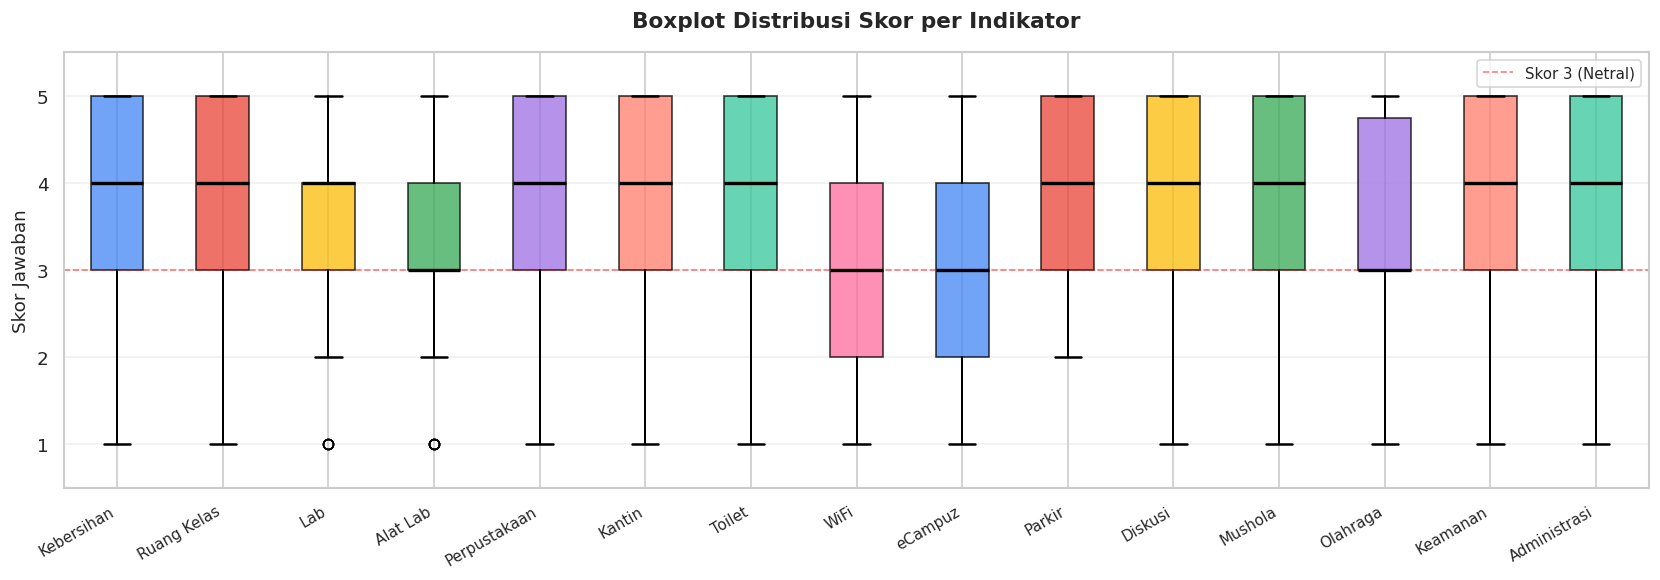

In [18]:
fig, ax = plt.subplots(figsize=(14, 5))
data_to_plot = [df[col].dropna().values for col in Q_COLS]
bp = ax.boxplot(data_to_plot, patch_artist=True, notch=False,
                medianprops={'color':'black','linewidth':2},
                whiskerprops={'linewidth':1.2},
                capprops={'linewidth':1.5})

for patch, color in zip(bp['boxes'], COLORS * 2):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_xticklabels([l.split(': ')[1] for l in Q_LABELS], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Skor Jawaban', fontsize=11)
ax.set_title('Boxplot Distribusi Skor per Indikator', fontsize=13, fontweight='bold', pad=15)
ax.set_ylim(0.5, 5.5)
ax.axhline(y=3, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Skor 3 (Netral)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig7_boxplot.png', bbox_inches='tight')
plt.show()

## 11. Analisis Saran (Word Frequency)

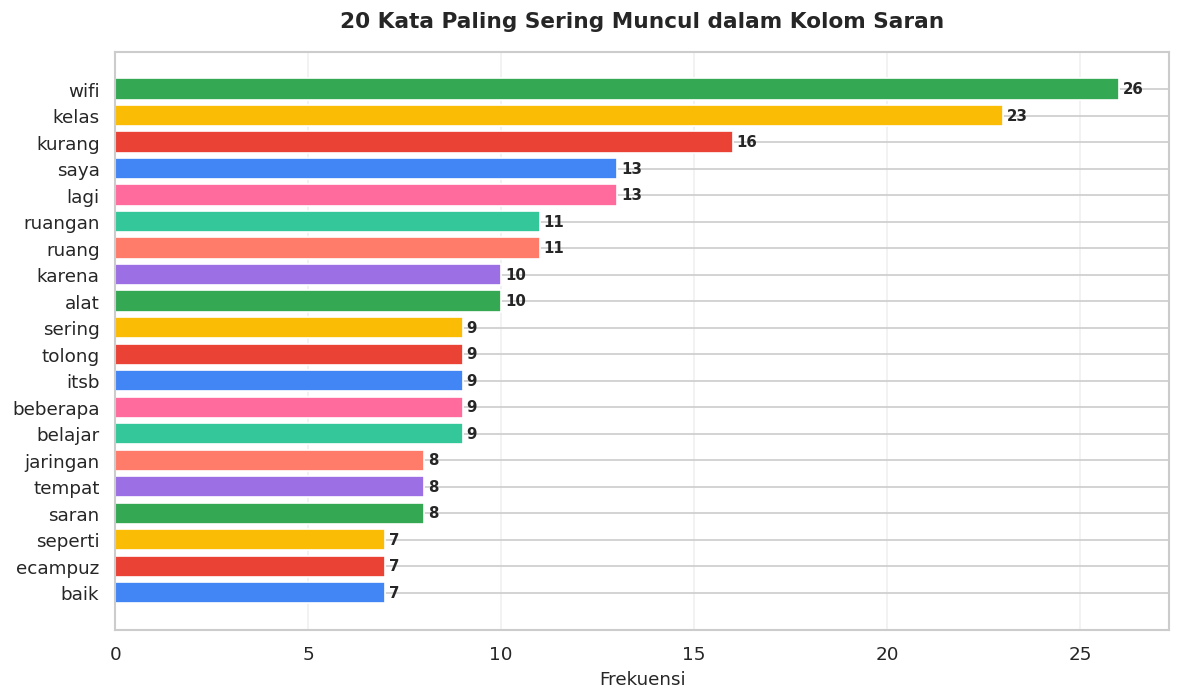

Top 10 kata dalam kolom saran:
  wifi: 26 kali
  kelas: 23 kali
  kurang: 16 kali
  saya: 13 kali
  lagi: 13 kali
  ruangan: 11 kali
  ruang: 11 kali
  karena: 10 kali
  alat: 10 kali
  sering: 9 kali


In [19]:
from collections import Counter
import re

# Gabungkan semua saran
saran_text = ' '.join(df['Saran'].dropna().astype(str).str.lower())

# Stopwords Indonesia sederhana
stopwords = set(['yang','dan','di','ke','dari','untuk','dengan','ini','itu',
                 'atau','juga','sudah','ada','tidak','bisa','lebih','agar',
                 'biar','aja','sih','ya','yg','nya','nya','nan','kalau','tapi',
                 'kita','kami','kampus','fasilitas','mahasiswa','bisa','harus',
                 'perlu','sangat','masih','lebih','banyak','buat'])

# Tokenisasi
words = re.findall(r'\b[a-zA-Z]{4,}\b', saran_text)
words_filtered = [w for w in words if w not in stopwords]

word_freq = Counter(words_filtered).most_common(20)
words_top, freqs_top = zip(*word_freq)

fig, ax = plt.subplots(figsize=(10, 6))
colors_wf = COLORS * 3
ax.barh(list(words_top)[::-1], list(freqs_top)[::-1],
        color=colors_wf[:len(words_top)], edgecolor='white')
for i, v in enumerate(list(freqs_top)[::-1]):
    ax.text(v + 0.1, i, str(v), va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Frekuensi', fontsize=11)
ax.set_title('20 Kata Paling Sering Muncul dalam Kolom Saran', fontsize=13, fontweight='bold', pad=15)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig8_word_freq.png', bbox_inches='tight')
plt.show()

print('Top 10 kata dalam kolom saran:')
for w, f in word_freq[:10]:
    print(f'  {w}: {f} kali')

## 12. Ringkasan Temuan & Kesimpulan

In [21]:
print('=' * 60)
print('RINGKASAN HASIL EDA — SURVEY KEPUASAN FASILITAS ITSB 2026')
print('=' * 60)
print(f'\n Total Responden       : {len(df)}')
print(f' Total Indikator       : 15')
print(f' Rata-rata Keseluruhan : {df[Q_COLS].mean().mean():.3f} / 5.00')
print()

mean_vals = df[Q_COLS].mean()
print(f' Skor Tertinggi : {Q_LABELS[mean_vals.argmax()]} = {mean_vals.max():.3f}')
print(f' Skor Terendah  : {Q_LABELS[mean_vals.argmin()]} = {mean_vals.min():.3f}')
print()

print('Distribusi kategori skor:')
sangat_baik = (mean_vals >= 4.0).sum()
baik = ((mean_vals >= 3.5) & (mean_vals < 4.0)).sum()
cukup = ((mean_vals >= 3.0) & (mean_vals < 3.5)).sum()
kurang = (mean_vals < 3.0).sum()
print(f'   Sangat Baik (≥4.0) : {sangat_baik} indikator')
print(f'   Baik (3.5-3.9)     : {baik} indikator')
print(f'   Cukup (3.0-3.4)    : {cukup} indikator')
print(f'   Perlu Perbaikan (<3): {kurang} indikator')
print()

print(' Rekomendasi Prioritas:')
print('  1. [TINGGI]  Upgrade infrastruktur WiFi kampus & server eCampuz')
print('  2. [SEDANG]  Tambah ruang kelas/gedung baru untuk kapasitas')
print('  3. [SEDANG]  Perbaikan harian toilet: tisu, kebersihan, loker')
print('  4. [PANJANG] Bangun fasilitas olahraga: lapangan multifungsi')
print('=' * 60)

RINGKASAN HASIL EDA — SURVEY KEPUASAN FASILITAS ITSB 2026

 Total Responden       : 127
 Total Indikator       : 15
 Rata-rata Keseluruhan : 3.686 / 5.00

 Skor Tertinggi : Q12: Mushola = 3.952
 Skor Terendah  : Q8: WiFi = 3.071

Distribusi kategori skor:
   Sangat Baik (≥4.0) : 0 indikator
   Baik (3.5-3.9)     : 12 indikator
   Cukup (3.0-3.4)    : 3 indikator
   Perlu Perbaikan (<3): 0 indikator

 Rekomendasi Prioritas:
  1. [TINGGI]  Upgrade infrastruktur WiFi kampus & server eCampuz
  2. [SEDANG]  Tambah ruang kelas/gedung baru untuk kapasitas
  3. [SEDANG]  Perbaikan harian toilet: tisu, kebersihan, loker
  4. [PANJANG] Bangun fasilitas olahraga: lapangan multifungsi
